In [2]:
import os
import numpy as np
import pandas as pd
import rasterio
from rasterio.windows import Window
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import matplotlib.pyplot as plt

# Paths
raw_img_path = "../data/raw/satellite_images/austin_sentinel_2023.tif"
raw_socio_path = "../data/raw/tabular/socio_economic_data.csv"
market_path = "../data/raw/tabular/energy_market_data.csv"

processed_img_dir = "../data/processed/images"
processed_tab_dir = "../data/processed/tabular"

os.makedirs(processed_img_dir, exist_ok=True)
os.makedirs(processed_tab_dir, exist_ok=True)

In [8]:
PATCH_SIZE = 224
STRIDE = 64  # <--- CHANGED: Small stride creates overlapping patches (More Data!)

def create_patches(tif_path, output_dir):
    # Clear existing patches to avoid mixing
    for f in os.listdir(output_dir):
        os.remove(os.path.join(output_dir, f))

    patches_metadata = []
    
    with rasterio.open(tif_path) as src:
        width = src.width
        height = src.height
        
        # Calculate steps
        # We use a while loop or range with step to slide the window
        x_steps = range(0, width - PATCH_SIZE, STRIDE)
        y_steps = range(0, height - PATCH_SIZE, STRIDE)
        
        print(f"Processing Image: {width}x{height} pixels")
        print(f"Grid Estimation: ~{len(y_steps)} rows x {len(x_steps)} cols")
        
        count = 0
        for i in tqdm(y_steps):
            for j in x_steps:
                # Define the window
                window = Window(j, i, PATCH_SIZE, PATCH_SIZE)
                
                # Read data
                img_data = src.read(window=window)
                
                # Check shapes to avoid edge errors
                if img_data.shape[1] != PATCH_SIZE or img_data.shape[2] != PATCH_SIZE:
                    continue

                # Filter out empty/black patches (0s)
                if np.mean(img_data) == 0:
                    continue
                    
                # Normalize (Sentinel-2 usually 0-3000)
                img_data = np.clip(img_data / 3000.0, 0, 1)
                
                # Transpose to (H, W, C)
                img_data = img_data.transpose(1, 2, 0)
                
                # Save patch
                patch_id = f"patch_{i}_{j}"
                save_path = os.path.join(output_dir, f"{patch_id}.npy")
                np.save(save_path, img_data)
                
                patches_metadata.append({
                    'patch_id': patch_id,
                    'file_path': save_path,
                    'row': i,
                    'col': j
                })
                count += 1
                
    print(f"Created {count} valid patches.")
    return pd.DataFrame(patches_metadata)

# Run the function
df_patches = create_patches(raw_img_path, processed_img_dir)

Processing Image: 1153x1002 pixels
Grid Estimation: ~13 rows x 15 cols


100%|██████████| 13/13 [00:07<00:00,  1.72it/s]

Created 195 valid patches.


In [9]:
# Load socio data
df_socio = pd.read_csv(raw_socio_path)

# We have N patches and M socio records.
# We will duplicate socio records to match the number of patches for this simulation.
# (In real life: Spatial Join using Geopandas)

n_patches = len(df_patches)
n_socio = len(df_socio)

# Repeat socio data to fill patches
df_final = pd.concat([df_patches.reset_index(drop=True), 
                      df_socio.sample(n=n_patches, replace=True).reset_index(drop=True)], axis=1)

print(f"Linked Data Shape: {df_final.shape}")
df_final.head()

Linked Data Shape: (195, 10)


,patch_id,file_path,row,col,latitude,longitude,median_income,population_density,avg_building_age,energy_consumption_kwh
0,patch_0_0,../data/processed/images\patch_0_0.npy,0,0,30.194440,-97.660231,51767.902939,2583,59,2095.749818
1,patch_0_64,../data/processed/images\patch_0_64.npy,0,64,30.173356,-97.845051,73026.583205,5286,64,3950.613600
2,patch_0_128,../data/processed/images\patch_0_128.npy,0,128,30.221885,-97.748022,105815.723889,7928,62,5823.099512
3,patch_0_192,../data/processed/images\patch_0_192.npy,0,192,30.285379,-97.797722,87654.480133,4528,62,3138.098959
4,patch_0_256,../data/processed/images\patch_0_256.npy,0,256,30.344546,-97.806502,17193.322621,7581,49,5273.224564


In [10]:
df_market = pd.read_csv(market_path, index_col=0, parse_dates=True)

# Calculate 30-day Rolling Volatility for Utilities (XLU)
# Volatility = Standard Deviation of returns
df_market['XLU_Return'] = df_market['Close_XLU'].pct_change()
df_market['Energy_Volatility'] = df_market['XLU_Return'].rolling(window=30).std()

# Get the average volatility for Summer 2023 (our image date)
avg_volatility = df_market.loc['2023-06-01':'2023-08-31', 'Energy_Volatility'].mean()

print(f"Average Energy Market Volatility (Summer 2023): {avg_volatility:.5f}")

# Add this global economic factor to all our local patches
df_final['market_volatility'] = avg_volatility

Average Energy Market Volatility (Summer 2023): 0.00922


In [11]:
# Select Features for Tabular Model
feature_cols = ['median_income', 'population_density', 'avg_building_age', 'market_volatility']
target_col = 'energy_consumption_kwh'

# Normalize Tabular Features
scaler = MinMaxScaler()
df_final[feature_cols] = scaler.fit_transform(df_final[feature_cols])

# Train/Test Split
train_df, test_df = train_test_split(df_final, test_size=0.2, random_state=42)

# Save
train_df.to_csv(os.path.join(processed_tab_dir, "train_data.csv"), index=False)
test_df.to_csv(os.path.join(processed_tab_dir, "test_data.csv"), index=False)

print("Data Split & Saved:")
print(f"   Train samples: {len(train_df)}")
print(f"   Test samples:  {len(test_df)}")

Data Split & Saved:
   Train samples: 156
   Test samples:  39


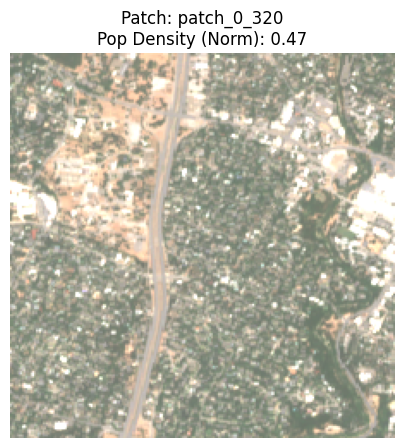

In [12]:
# Load one random patch
sample_row = train_df.iloc[0]
patch_path = sample_row['file_path']
patch_img = np.load(patch_path)

plt.figure(figsize=(5,5))
plt.imshow(patch_img) # RGB
plt.title(f"Patch: {sample_row['patch_id']}\nPop Density (Norm): {sample_row['population_density']:.2f}")
plt.axis('off')
plt.show()